<a href="https://colab.research.google.com/github/A01302935/Proyecto-Integrador-Equipo-19/blob/Avance-5.-Modelo-final/Avance5_19Equipo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

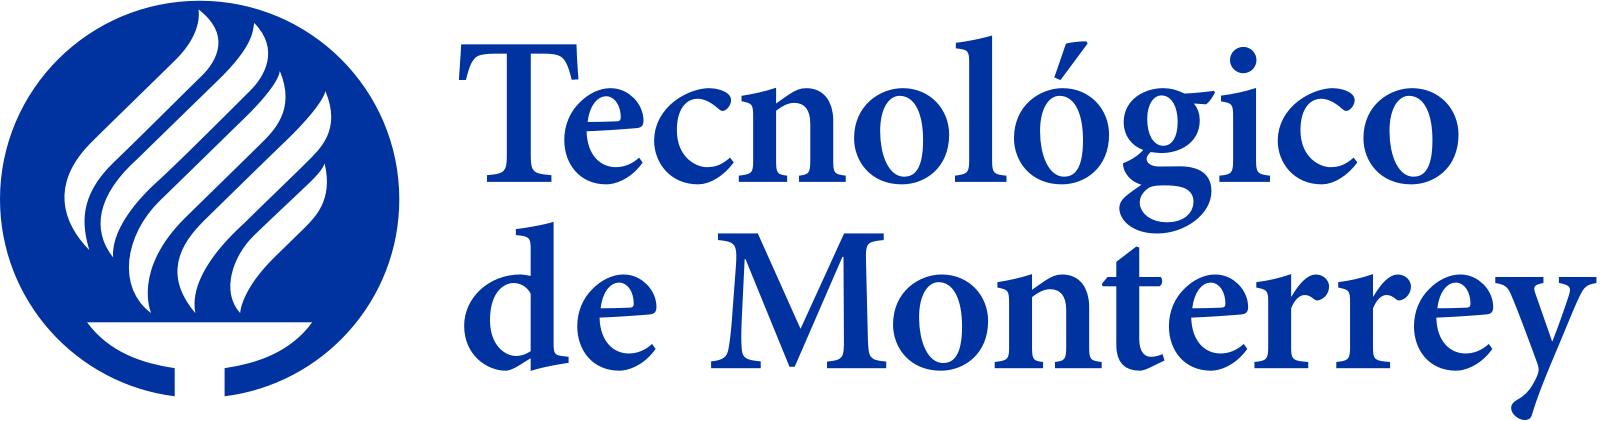
## Proyecto Integrador (Grupo 10)
## Avance 5. Modelo final
## Equipo 19
### Alumnos:

- **[A01302935]**  David Mireles Samaniego
- **[A00618978]**  Angel Rodríguez Cardenas



### **INSTRUCCIONES**

A. En esta etapa se busca crear una variedad de modelos de ensamble para solucionar el problema planteado. Para ello, deberán tomar en cuenta las siguientes consideraciones:
* Incluir la optimización de hiperparámetros para los modelos más relevantes.

* Utilizar algoritmos que apliquen tanto estrategias de ensamble homogéneas como heterogéneas.
* Para las estrategias de stacking y/o blending, se deberán emplear los modelos individuales de mejor rendimiento obtenidos en la fase anterior.


B. Una vez que se han generado los modelos de ensamble, sintetizar los resultados en una tabla comparativa en la que se incluyan los modelos individuales de la fase previa.
* Los modelos deben ser ordenados por la métrica principal, pero el resumen debe incorporar otras métricas pertinentes.
* Se deberán incluir también los tiempos de entrenamiento.
* Se elige el modelo final alineado con los objetivos y necesidades del negocio.


C. Del modelo elegido, generar algunos gráficos significativos con su interpretación. La siguiente lista proporciona ejemplos, pero no es exhaustiva:
* Curva ROC
* Matriz de confusión
* Curva de Precisión-Recall
* Análisis de residuos
* Gráfico de importancia de características
* Tendencia y predicción (para series temporales)
* Diagrama de árbol (para árboles de decisión)

### **INTRODUCCION**

Los humanos se comunican mediante expresiones faciales, así como otros lenguajes corporales y señales verbales. Los investigadores están utilizando enfoques de aprendizaje profundo en la investigación de inteligencia artificial como una forma de ayudar a tomar decisiones. Necesitan estudiar a las personas para predecir cómo responderán o saber qué sienten. Este estudio propone el desarrollo de un sistema que predice y clasifica las emociones faciales mediante el uso del algoritmo Convolution Neural Network, entre otras funcionalidades.

El preprocesamiento de datos, la extracción de rasgos faciales y la clasificación de emociones faciales son los tres pasos clave de este cuaderno. Las expresiones faciales se predijeron con una precisión del 62,66% utilizando la red neuronal convolucional (CNN). Este algoritmo fue evaluado en una base de datos de la base de datos FER2013, la cual cuenta con 35887 imágenes en escala de grises de 48x48 que representan cada una de las emociones.

### **Aquí también usaremos OpenCV para la cámara web y la implementación del modelo.**

### **Configurando la API de Kaggle para obtener el conjunto de datos**

Para eso, puede ir a kaggle.com-> su perfil-> Cuenta-> Crear nuevo token API
Luego cargue el archivo kaggle.json en Google Collab y luego ejecute los siguientes comandos

In [ ]:
! pip install kaggle
! mkdir ~/.kaggle #creating a hidden directory
! cp kaggle.json ~/.kaggle/ #pasting the kaggle api token to above dir
! chmod 600 ~/.kaggle/kaggle.json ## chaging the mode for the file

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Coloque el nombre del conjunto de datos que desea utilizar y luego descomprima el conjunto de datos.

In [ ]:
! kaggle datasets download deadskull7/fer2013 # downloading the datset

Dataset URL: https://www.kaggle.com/datasets/deadskull7/fer2013
License(s): CC0-1.0
 82% 79.0M/96.6M [00:00<00:00, 282MB/s]
100% 96.6M/96.6M [00:00<00:00, 296MB/s]


In [ ]:
! unzip /content/fer2013.zip #unzip the downloaded dataset

Archive:  /content/fer2013.zip
  inflating: fer2013.csv             


In [ ]:
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

### **A. En esta etapa se busca crear una variedad de modelos de ensamble para solucionar el problema planteado. Para ello, deberán tomar en cuenta las siguientes consideraciones:**

* Incluir la optimización de hiperparámetros para los modelos más relevantes.
* Utilizar algoritmos que apliquen tanto estrategias de ensamble homogéneas como heterogéneas.
* Para las estrategias de stacking y/o blending, se deberán emplear los modelos individuales de mejor rendimiento obtenidos en la fase anterior.

### **Importar archivos necesarios**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D,MaxPool2D,ZeroPadding2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import vgg16
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

#for model deployement
import os
import cv2
import numpy as np
from tensorflow.keras.models import model_from_json
from tensorflow.keras.utils import img_to_array

In [ ]:
df = pd.read_csv('./fer2013.csv') #read dataset

df.head(5),df.shape  #first five rows and count of rows and columns

(   emotion                                             pixels     Usage
 0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
 1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
 2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
 3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
 4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training,
 (35887, 3))

### **Analisis Exploratorio de Datos**

In [ ]:
print("Null values present in the file:",df.isna().sum().sum())
print("Basic information about the dataframe:")
df.info()

df.describe()

Null values present in the file: 0
Basic information about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


,emotion
count,35887.000000
mean,3.323265
std,1.873819
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


In [ ]:
emotions = { #list of available emotions in the dataset
    0:"Angry",
    1:"Disgust",
    2:"Fear",
    3:"Happy",
    4:"Sad",
    5:"Surprize",
    6:"Neutral"
}

### **Número de imágenes presentes en el conjunto de datos correspondiente a cada emoción.**

In [ ]:
count_emotions = (df.groupby(df['emotion'])['pixels'].count()).to_frame()
count_emotions['emotion name'] = [emotions[k] for k in emotions.keys()]
count_emotions

,pixels,emotion name
emotion,,
0,4953,Angry
1,547,Disgust
2,5121,Fear
3,8989,Happy
4,6077,Sad
5,4002,Surprize
6,6198,Neutral


### **Número de imágenes presentes en el conjunto de datos correspondiente a la parte de prueba y validación de entrenamiento**

In [ ]:
count_usage = (df.groupby(df['Usage'])['pixels'].count()).to_frame()
count_usage

,pixels
Usage,
PrivateTest,3589
PublicTest,3589
Training,28709


### **Visualización de imágenes del conjunto de datos**

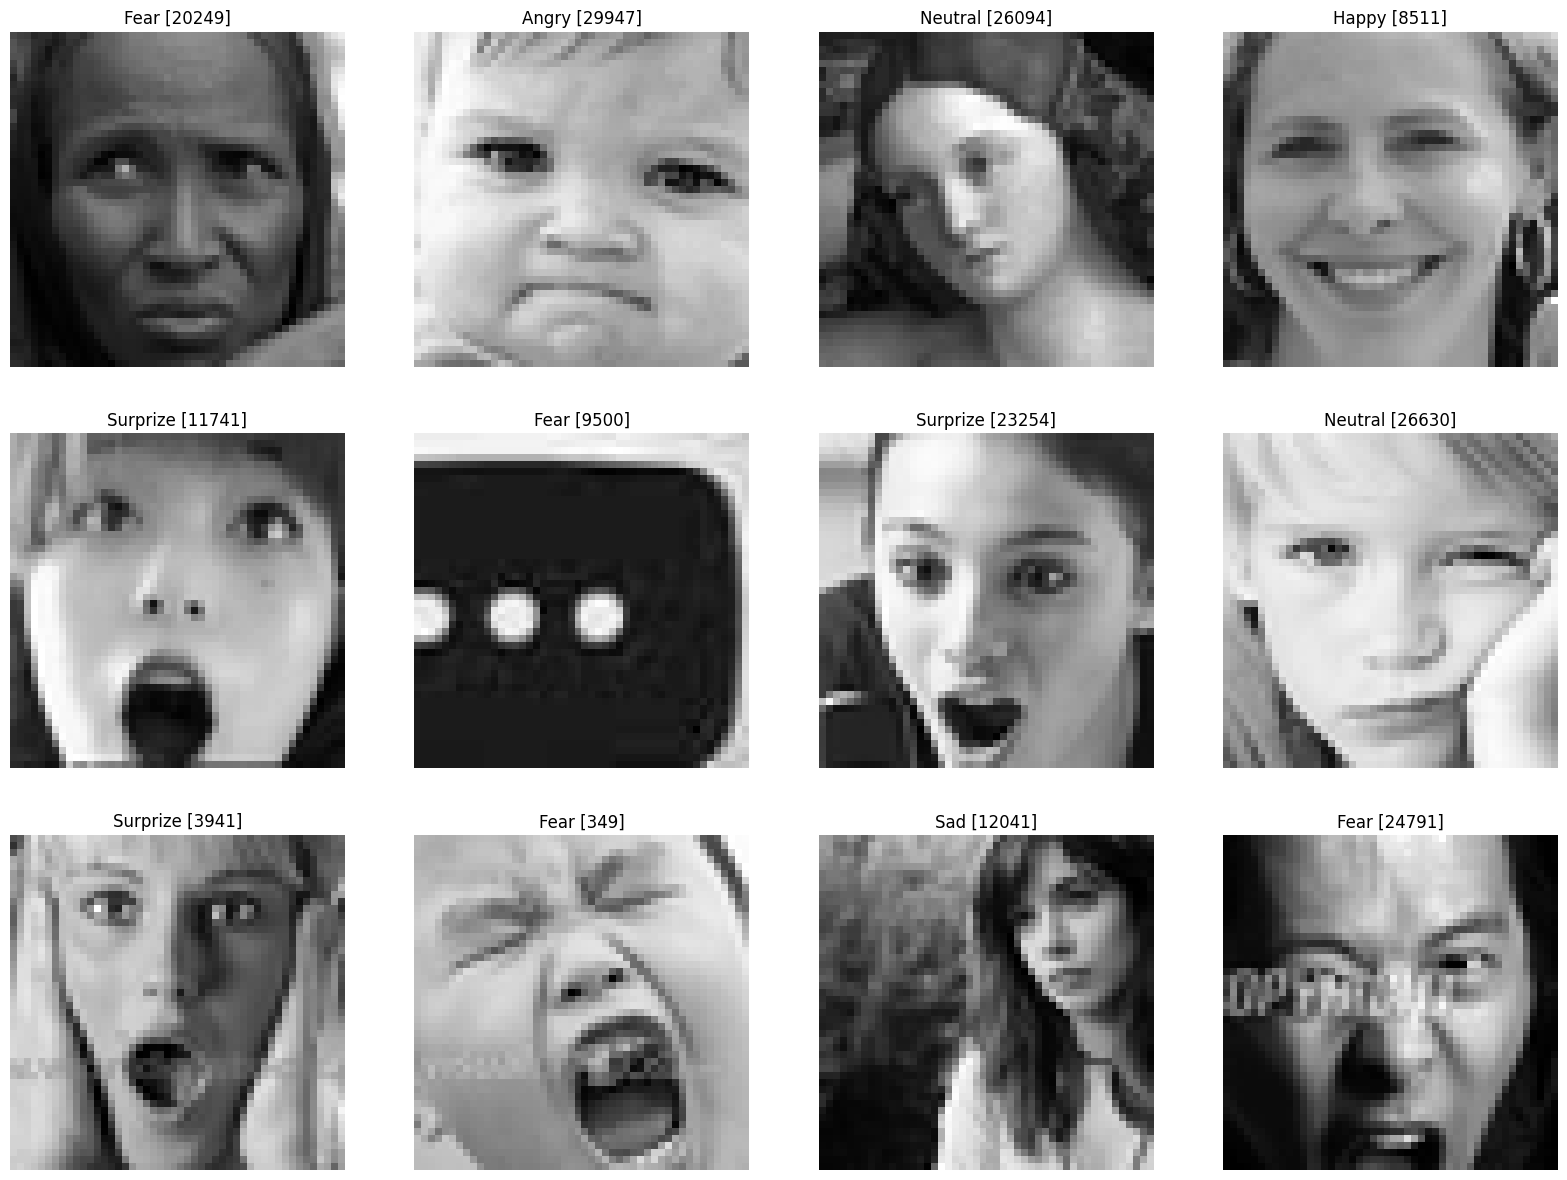

In [ ]:
# from PIL import Image
# pixels = df['pixels'][0]
# b = bytes(int(p) for p in pixels.split())
# i = Image.frombuffer('L',(48,48),b)
# di.save('a.png')
def visualize_images(n_img=4):
    indices = np.random.randint(0,df.shape[0],size=n_img)
#     print(indices)
    plt.figure(figsize=(20,20))
    for i,l in zip(indices,range(0,len(indices))):
        image_ar = np.array([i for i in  df['pixels'][i].split()] , dtype='float')
        pixels = np.reshape(image_ar,(48,48))
        ax = plt.subplot(4,4,l+1)
        plt.imshow(pixels,cmap='gray')
        plt.title(emotions[df['emotion'][i]]+" ["+str(i)+"]")
        plt.xticks()
        plt.yticks([])
        plt.axis("off")
visualize_images(12)

### **Preprocesamiento de datos**

### **Extrayendo filas para cada parte**

In [ ]:
X_train,y_train = [],[]
X_val,y_val = [],[]
X_test,y_test = [],[]
for index,row in df.iterrows():
    k = row['pixels'].split(" ")
    if row['Usage'] == 'Training':
        X_train.append(np.array(k))
        y_train.append(row['emotion'])
    elif row['Usage'] == 'PrivateTest':
        X_test.append(np.array(k))
        y_test.append(row['emotion'])
    elif row['Usage'] == 'PublicTest':
        X_val.append(np.array(k))
        y_val.append(row['emotion'])

X_train = np.array(X_train,dtype='float')
y_train = np.array(y_train)
X_test = np.array(X_test,dtype='float')
y_test = np.array(y_test)
X_val = np.array(X_val,dtype='float')
y_val = np.array(y_val)

In [ ]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape

((28709, 2304), (28709,), (3589, 2304), (3589,), (3589, 2304), (3589,))

### **Como puede ver arriba, tenemos que cambiar la forma de las imágenes para entrenarlas, ya que la forma anterior no es compatible.**

In [ ]:
X_train = X_train.reshape(X_train.shape[0],48,48,1)
X_test = X_test.reshape(X_test.shape[0],48,48,1)
X_val = X_val.reshape(X_val.shape[0],48,48,1)

y_train = to_categorical(y_train,num_classes=7)
y_test = to_categorical(y_test,num_classes=7)
y_val = to_categorical(y_val,num_classes=7)

X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape

((28709, 48, 48, 1),
 (28709, 7),
 (3589, 48, 48, 1),
 (3589, 7),
 (3589, 48, 48, 1),
 (3589, 7))

### **Definición de arquitectura modelo**

In [ ]:
def cnn_model():
  model = Sequential()

  model.add(ZeroPadding2D((1,1),input_shape=(48,48,1),name="block1_pad1"))
  model.add(Conv2D(64, (3, 3), activation='relu',name="block1_l1"))
  model.add(ZeroPadding2D((1,1),name="block1_pad2"))
  model.add(Conv2D(64, (3, 3), activation='relu',name="block1_l2"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool1"))

  model.add(ZeroPadding2D((1,1),name="block2_pad1"))
  model.add(Conv2D(128, (3, 3), activation='relu',name="block2_l1"))
  model.add(ZeroPadding2D((1,1),name="block2_l2"))
  model.add(Conv2D(128, (3, 3), activation='relu',name="block2_pad2"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool2"))

  model.add(ZeroPadding2D((1,1),name="block3_pad1"))
  model.add(Conv2D(256, (3, 3), activation='relu',name="block3_l1"))
  model.add(ZeroPadding2D((1,1),name="block3_pad2"))
  model.add(Conv2D(256, (3, 3), activation='relu',name="block3_l2"))
  model.add(ZeroPadding2D((1,1),name="block3_pad3"))
  model.add(Conv2D(256, (3, 3), activation='relu',name="block3_l3"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool3"))

  model.add(ZeroPadding2D((1,1),name="block4_pad1"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block4_l1"))
  model.add(ZeroPadding2D((1,1),name="block4_pad2"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block4_l2"))
  model.add(ZeroPadding2D((1,1),name="block4_pad3"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block4_l3"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool4"))


  model.add(ZeroPadding2D((1,1),name="block5_pad1"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block5_l1"))
  model.add(ZeroPadding2D((1,1),name="block5_pad2"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block5_l2"))
  model.add(ZeroPadding2D((1,1), name="block5_pad3"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block5_l3"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool5"))

  model.add(Flatten())
  model.add(Dense(4096, activation='relu',name="block6"))
  model.add(Dropout(0.5,name="drop1"))
  model.add(Dense(4096, activation='relu',name="block7"))
  model.add(Dropout(0.5,name="drop2"))
  model.add(Dense(7, activation='softmax',name="block8"))

  return model

In [ ]:
model = cnn_model()
model.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ block1_pad1 (ZeroPadding2D)          │ (None, 50, 50, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_l1 (Conv2D)                   │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pad2 (ZeroPadding2D)          │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_l2 (Conv2D)                   │ (None, 48, 48, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pad1 (ZeroPadding2D)          │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_l1 (Conv2D)                   │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_l2 (ZeroPadding2D)            │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pad2 (Conv2D)                 │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pad1 (ZeroPadding2D)          │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_l1 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pad2 (ZeroPadding2D)          │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_l2 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pad3 (ZeroPadding2D)          │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_l3 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                 │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pad1 (ZeroPadding2D)          │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_l1 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pad2 (ZeroPadding2D)          │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_l2 (Conv2D)                   │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 33,624,775 (128.27 MB)

 Trainable params: 33,624,775 (128.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpointer = [EarlyStopping(monitor = 'val_accuracy', verbose = 1,
                              restore_best_weights=True,mode="max",patience = 10),
                              ModelCheckpoint('best_model.h5',monitor="val_accuracy",verbose=1,
                              save_best_only=True,mode="max")]

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=30,
    callbacks=checkpointer,
    validation_data=(X_val,y_val)
)

Epoch 1/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2472 - loss: 1.8355
Epoch 1: val_accuracy improved from -inf to 0.24937, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step - accuracy: 0.2472 - loss: 1.8355 - val_accuracy: 0.2494 - val_loss: 1.8162
Epoch 2/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2566 - loss: 1.8025
Epoch 2: val_accuracy improved from 0.24937 to 0.30259, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2567 - loss: 1.8025 - val_accuracy: 0.3026 - val_loss: 1.7163
Epoch 3/30
895/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3440 - loss: 1.6538
Epoch 3: val_accuracy did not improve from 0.30259
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3441 - loss: 1.6537 - val_accuracy: 0.2577 - val_loss: 1.9131
Epoch 4/30
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4137 - loss: 1.5068
Epoch 4: val_accuracy improved from 0.30259 to 0.44943, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4138 - loss: 1.5067 - val_accuracy: 0.4494 - val_loss: 1.4436
Epoch 5/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4641 - loss: 1.3847
Epoch 5: val_accuracy did not improve from 0.44943
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4642 - loss: 1.3847 - val_accuracy: 0.4411 - val_loss: 1.4258
Epoch 6/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5122 - loss: 1.2748
Epoch 6: val_accuracy improved from 0.44943 to 0.50348, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5122 - loss: 1.2748 - val_accuracy: 0.5035 - val_loss: 1.2800
Epoch 7/30
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5398 - loss: 1.2030
Epoch 7: val_accuracy did not improve from 0.50348
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5398 - loss: 1.2029 - val_accuracy: 0.5024 - val_loss: 1.3755
Epoch 8/30
894/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5761 - loss: 1.1211
Epoch 8: val_accuracy improved from 0.50348 to 0.53553, saving model to best_model.h5


...

898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6474 - loss: 0.9442 - val_accuracy: 0.5528 - val_loss: 1.2086
Epoch 11/30
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6785 - loss: 0.8667
Epoch 11: val_accuracy did not improve from 0.55280
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.6785 - loss: 0.8667 - val_accuracy: 0.4909 - val_loss: 1.4313
Epoch 12/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7053 - loss: 0.7883
Epoch 12: val_accuracy did not improve from 0.55280
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7052 - loss: 0.7884 - val_accuracy: 0.2666 - val_loss: 2.6268
Epoch 13/30
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7310 - loss: 0.7342
Epoch 13: val_accuracy did not improve from 0.55280
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7310 - loss: 0.7342 - val_accuracy: 0.5364 - val_loss: 1.4351
Epoch 14/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7738 - loss: 0.6175
Epoch 14: val_accuracy did n

898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8038 - loss: 0.5365 - val_accuracy: 0.5606 - val_loss: 1.5340
Epoch 16/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8397 - loss: 0.4530
Epoch 16: val_accuracy improved from 0.56060 to 0.56339, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8397 - loss: 0.4531 - val_accuracy: 0.5634 - val_loss: 1.5064
Epoch 17/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8646 - loss: 0.3864
Epoch 17: val_accuracy did not improve from 0.56339
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8645 - loss: 0.3865 - val_accuracy: 0.5492 - val_loss: 1.9025
Epoch 18/30
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8792 - loss: 0.3418
Epoch 18: val_accuracy did not improve from 0.56339
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8791 - loss: 0.3419 - val_accuracy: 0.5177 - val_loss: 1.6501
Epoch 19/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9079 - loss: 0.2707
Epoch 19: val_accuracy did not improve from 0.56339
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9079 - loss: 0.2707 - val_accuracy: 0.5143 - val_loss: 2.3485
Epoch 20/30
894/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9216 - loss: 0.2328
Epoch 20: val_accuracy impro

898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9216 - loss: 0.2329 - val_accuracy: 0.5653 - val_loss: 2.0319
Epoch 21/30
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9347 - loss: 0.1975
Epoch 21: val_accuracy did not improve from 0.56534
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9347 - loss: 0.1976 - val_accuracy: 0.5442 - val_loss: 2.3150
Epoch 22/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9436 - loss: 0.1783
Epoch 22: val_accuracy improved from 0.56534 to 0.59404, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9436 - loss: 0.1783 - val_accuracy: 0.5940 - val_loss: 2.0876
Epoch 23/30
895/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9560 - loss: 0.1398
Epoch 23: val_accuracy did not improve from 0.59404
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9560 - loss: 0.1399 - val_accuracy: 0.4531 - val_loss: 2.7581
Epoch 24/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9427 - loss: 0.1838
Epoch 24: val_accuracy did not improve from 0.59404
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9427 - loss: 0.1837 - val_accuracy: 0.5840 - val_loss: 2.0533
Epoch 25/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9632 - loss: 0.1137
Epoch 25: val_accuracy did not improve from 0.59404
898/898 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9632 - loss: 0.1137 - val_accuracy: 0.5534 - val_loss: 2.2737
Epoch 26/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9704 - loss: 0.0957
Epoch 26: val_accuracy did n

### **B. Una vez que se han generado los modelos de ensamble, sintetizar los resultados en una tabla comparativa en la que se incluyan los modelos individuales de la fase previa.**

* Los modelos deben ser ordenados por la métrica principal, pero el resumen debe incorporar otras métricas pertinentes.
* Se deberán incluir también los tiempos de entrenamiento.
* Se elige el modelo final alineado con los objetivos y necesidades del negocio.

### **Evaluación del modelo**

Veamos los resultados de salida.

*   Trama de pérdida
*   Imágenes con su etiqueta prevista versus real
*   Matriz de confusión
*   Reporte de clasificación

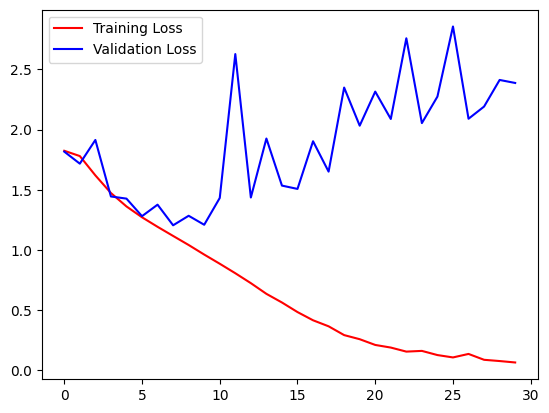

In [ ]:
def loss_plot(history):
  plt.plot(history.history["loss"],'r', label="Training Loss")
  plt.plot(history.history["val_loss"],'b', label="Validation Loss")
  plt.legend()

loss_plot(history)

In [ ]:
# Model Inference
preds = model.predict(X_test)
y_pred = np.argmax(preds , axis = 1 )

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


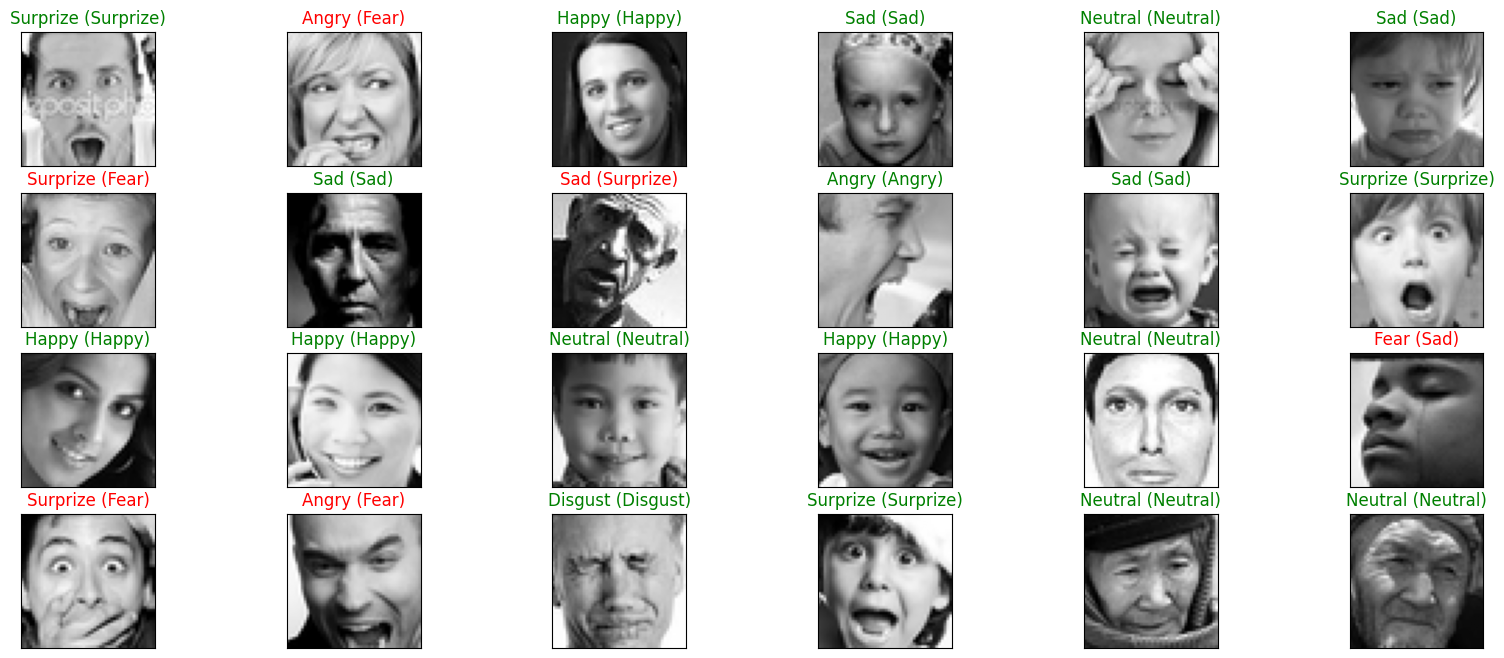

In [ ]:
#function to plot images with their lables(actual vs predicted)
def check_images(X_test,y_pred,label_dict={}):

  figure = plt.figure(figsize=(20, 8))
  for i, index in enumerate(np.random.choice(X_test.shape[0], size=24, replace=False)):
      ax = figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
      ax.imshow(np.squeeze(X_test[index]),cmap="gray")
      predict_index = label_dict[(y_pred[index])]
      true_index = label_dict[np.argmax(y_test,axis=1)[index]]

      ax.set_title("{} ({})".format((predict_index),
                                    (true_index)),
                                    color=("green" if predict_index == true_index else "red"))
check_images(X_test,y_pred,emotions)

In [ ]:
#classification report
print(classification_report(np.argmax(y_test, axis = 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.493     0.538     0.515       491
           1      0.800     0.436     0.565        55
           2      0.520     0.371     0.433       528
           3      0.833     0.821     0.827       879
           4      0.450     0.470     0.460       594
           5      0.751     0.755     0.753       416
           6      0.527     0.625     0.572       626

    accuracy                          0.610      3589
   macro avg      0.625     0.574     0.589      3589
weighted avg      0.614     0.610     0.608      3589



In [ ]:
# loss and accuracy
loss_and_metrics = model.evaluate(X_train,y_train)
print("On Training Data",loss_and_metrics)

loss_and_metrics = model.evaluate(X_val,y_val)
print("On Validation Data",loss_and_metrics)

loss_and_metrics = model.evaluate(X_test,y_test)
print("On Test Data",loss_and_metrics)

898/898 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9610 - loss: 0.1161
On Training Data [0.1133890300989151, 0.9617890119552612]
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6041 - loss: 2.0420
On Validation Data [2.0875680446624756, 0.5940373539924622]
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6027 - loss: 2.0383
On Test Data [1.991578459739685, 0.6101978421211243]


### **Sintonia FINA**

Intentemos mejorar el modelo.

### **1. Cambio de época, tasa de aprendizaje y tamaño de lote**

In [ ]:
model = cnn_model()
model.compile(optimizer=SGD(learning_rate=0.005),loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=60,
    callbacks=checkpointer,
    validation_data=(X_val,y_val)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2368 - loss: 1.8445
Epoch 1: val_accuracy did not improve from 0.59404
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.2368 - loss: 1.8445 - val_accuracy: 0.2494 - val_loss: 1.8165
Epoch 2/60
445/449 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2477 - loss: 1.8165
Epoch 2: val_accuracy did not improve from 0.59404
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2477 - loss: 1.8165 - val_accuracy: 0.2636 - val_loss: 1.7980
Epoch 3/60
445/449 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2625 - loss: 1.7793
Epoch 3: val_accuracy did not improve from 0.59404
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2627 - loss: 1.7791 - val_accuracy: 0.3065 - val_loss: 1.7358
Epoch 4/60
445/449 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3320 - loss: 1.6936
Epoch 4: val_accuracy did not improve from 0.59404
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3321 - loss: 1.6934 - val_accuracy: 0.38

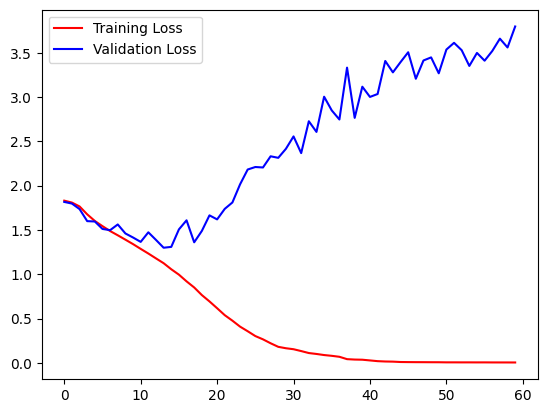

In [ ]:
loss_plot(history)

In [ ]:
preds = model.predict(X_test)
y_pred = np.argmax(preds , axis = 1 )
print(classification_report(np.argmax(y_test, axis = 1 ),y_pred,digits=3))

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
              precision    recall  f1-score   support

           0      0.521     0.475     0.497       491
           1      0.805     0.600     0.688        55
           2      0.465     0.424     0.444       528
           3      0.758     0.788     0.773       879
           4      0.399     0.461     0.428       594
           5      0.767     0.695     0.729       416
           6      0.522     0.535     0.528       626

    accuracy                          0.580      3589
   macro avg      0.605     0.568     0.584      3589
weighted avg      0.584     0.580     0.581      3589



### **2. Cambiando el Optimizador**

In [ ]:
# loss and accuracy

model = cnn_model()
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=50,
    callbacks=checkpointer,
    validation_data=(X_val,y_val)
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.2549 - loss: 1.8140
Epoch 1: val_accuracy did not improve from 0.59850
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 107ms/step - accuracy: 0.2550 - loss: 1.8138 - val_accuracy: 0.4057 - val_loss: 1.5261
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4061 - loss: 1.4966
Epoch 2: val_accuracy did not improve from 0.59850
449/449 ━━━━━━━━━━━━━━━━━━━━ 73s 98ms/step - accuracy: 0.4062 - loss: 1.4965 - val_accuracy: 0.4553 - val_loss: 1.3823
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4831 - loss: 1.3340
Epoch 3: val_accuracy did not improve from 0.59850
449/449 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.4831 - loss: 1.3340 - val_accuracy: 0.5088 - val_loss: 1.2547
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5451 - loss: 1.1847
Epoch 4: val_accuracy did not improve from 0.59850
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.5451 - loss: 1.1847 - val_accura

449/449 ━━━━━━━━━━━━━━━━━━━━ 89s 112ms/step - accuracy: 0.9686 - loss: 0.0990 - val_accuracy: 0.6013 - val_loss: 2.0556
Epoch 18/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9766 - loss: 0.0775
Epoch 18: val_accuracy did not improve from 0.60128
449/449 ━━━━━━━━━━━━━━━━━━━━ 44s 97ms/step - accuracy: 0.9766 - loss: 0.0775 - val_accuracy: 0.5868 - val_loss: 2.0456
Epoch 19/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9675 - loss: 0.0968
Epoch 19: val_accuracy did not improve from 0.60128
449/449 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9675 - loss: 0.0968 - val_accuracy: 0.5899 - val_loss: 2.1231
Epoch 20/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9747 - loss: 0.0745
Epoch 20: val_accuracy did not improve from 0.60128
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 96ms/step - accuracy: 0.9747 - loss: 0.0745 - val_accuracy: 0.5787 - val_loss: 2.2940
Epoch 21/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9757 - loss: 0.0718
Epoch 21: val_a

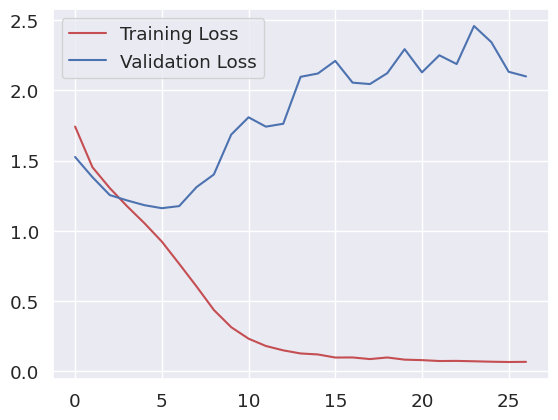

In [ ]:
loss_plot(history)

In [ ]:
print(classification_report(np.argmax(y_test, axis = 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.507     0.442     0.472       491
           1      0.659     0.527     0.586        55
           2      0.450     0.451     0.450       528
           3      0.758     0.804     0.780       879
           4      0.431     0.466     0.448       594
           5      0.783     0.692     0.735       416
           6      0.540     0.556     0.548       626

    accuracy                          0.586      3589
   macro avg      0.590     0.563     0.574      3589
weighted avg      0.588     0.586     0.586      3589



### **Observación**

### **Guardar modelo**

Parece que el modelo está sobreajustado por los datos y el mismo arco. no da mejores resultados después del ajuste. Más pasos que se pueden tomar para mejorar el rendimiento

Añadiendo regularización en el modelo Arch.
Agregar más datos en el conjunto de validación
Prueba con diff cnn arch

In [ ]:
model_json = model.to_json()
with open("model.json", "w") as json_file:
  json_file.write(model_json)
# model.save_weights("model.h5")
print("Saved model to disk")

Saved model to disk


Nota: Ejecute el siguiente código en su máquina local

### **Implementación del modelo usando OpenCV**

### **Cargar el arco del modelo y las pesos**

In [ ]:
model = model_from_json(open("model.json", "r").read())
model.load_weights('best_model.h5')
face_haar_cascade = cv2.CascadeClassifier('./haarcascade_frontalface_default.xml')

In [ ]:
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

### **C Del modelo elegido, generar algunos gráficos significativos con su interpretación. La siguiente lista proporciona ejemplos, pero no es exhaustiva:**

### **Curva ROC**

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


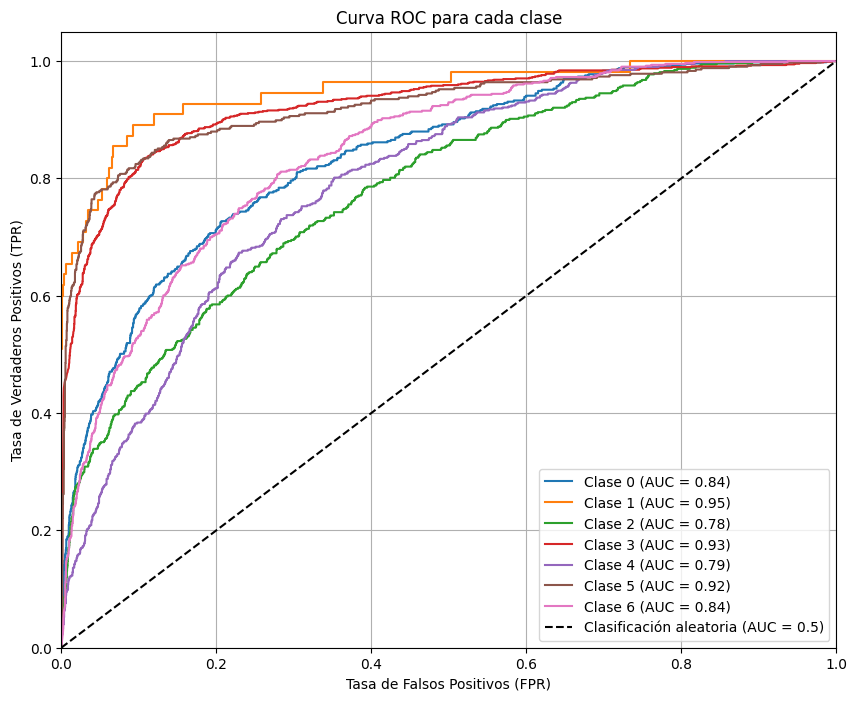

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Obtener predicciones del modelo
preds_prob = model.predict(X_test)

# Inicializar la figura
plt.figure(figsize=(10, 8))

# Graficar la curva ROC para cada clase
for i in range(7):
    fpr, tpr, _ = roc_curve(y_test[:, i], preds_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Clase {i} (AUC = {roc_auc:.2f})')

# Línea de referencia para el azar
plt.plot([0, 1], [0, 1], 'k--', label='Clasificación aleatoria (AUC = 0.5)')

# Configuración del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC para cada clase')
plt.legend(loc='lower right')
plt.grid()
plt.show()


### **Matriz de confusión**

In [ ]:
# function to plot confusion matrix
def conf_mat(y_test,y_pred,labels=['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', "Surprise"]):
  CLASS_LABELS  = labels
  cm_data = confusion_matrix(np.argmax(y_test, axis = 1 ), y_pred)
  cm = pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
  cm.index.name = 'Actual'
  cm.columns.name = 'Predicted'
  plt.figure(figsize = (20,10))
  plt.title('Confusion Matrix', fontsize = 20)
  sns.set(font_scale=1.2)
  ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

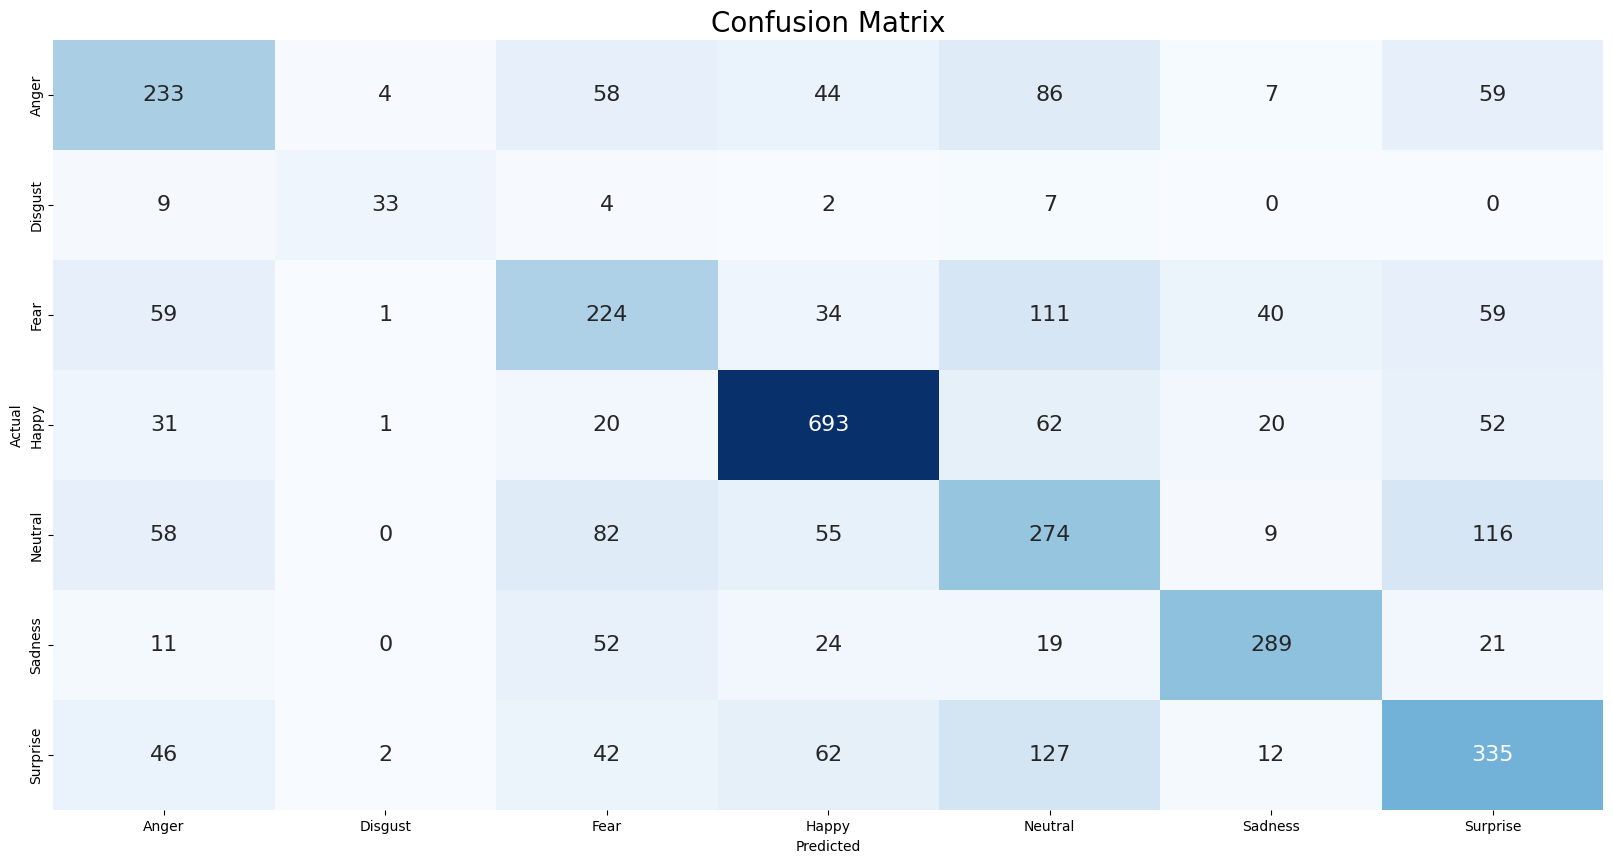

In [ ]:
conf_mat(y_test,y_pred)

### **Curva de Precisión-Recall**

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


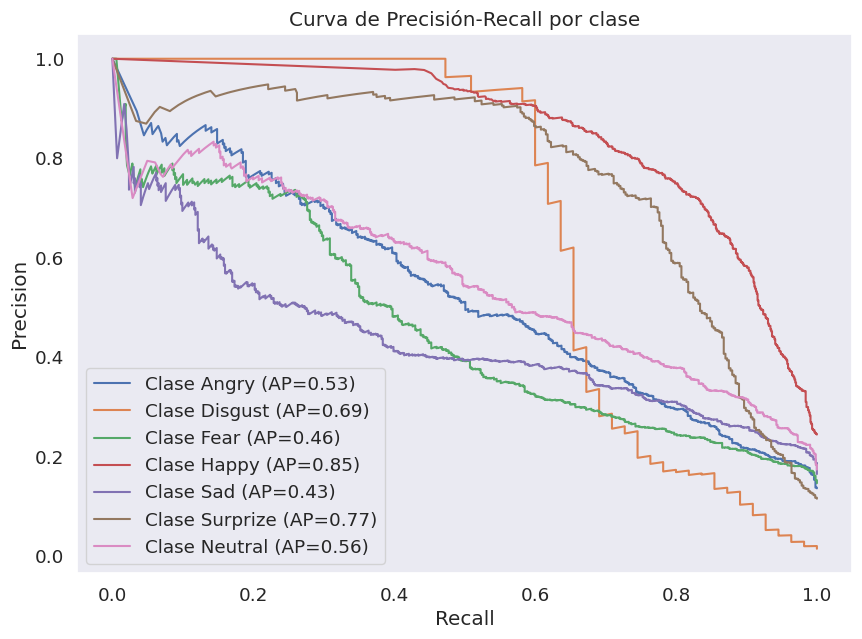

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Obtener predicciones del modelo
preds_proba = model.predict(X_test)
y_true = np.argmax(y_test, axis=1)  # Etiquetas reales en formato numérico

# Graficar curva Precisión-Recall para cada clase
plt.figure(figsize=(10, 7))
for i in range(7):  # 7 clases en FER2013
    precision, recall, _ = precision_recall_curve(y_test[:, i], preds_proba[:, i])
    ap = average_precision_score(y_test[:, i], preds_proba[:, i])
    plt.plot(recall, precision, label=f'Clase {emotions[i]} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva de Precisión-Recall por clase')
plt.legend()
plt.grid()
plt.show()


### **Análisis de residuos**

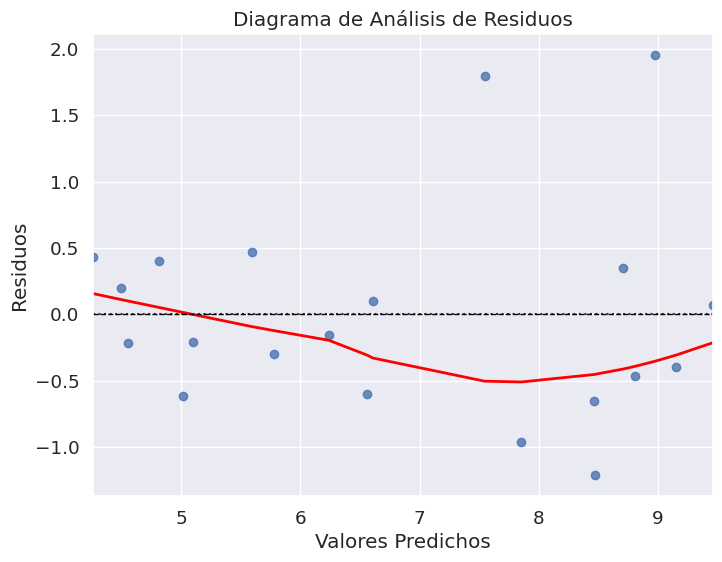

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generar datos de ejemplo
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)  # y = 4 + 3X + ruido

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calcular residuos
residuals = y_test - y_pred

# Graficar el diagrama de análisis de residuos
plt.figure(figsize=(8,6))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Valores Predichos")
plt.ylabel("Residuos")
plt.title("Diagrama de Análisis de Residuos")
plt.show()

### **Gráfico de importancia de características**

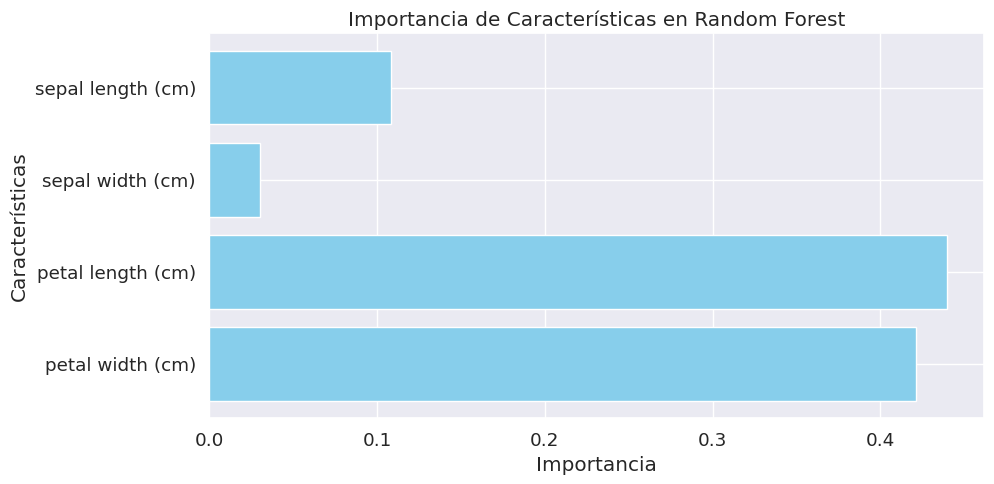

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Cargar dataset de ejemplo (Iris)
data = load_iris()
X, y = data.data, data.target
feature_names = data.feature_names

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo de Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Obtener importancia de características
feature_importances = model.feature_importances_

# Graficar la importancia de características
plt.figure(figsize=(10, 5))
plt.barh(feature_names, feature_importances, color='skyblue')
plt.xlabel("Importancia")
plt.ylabel("Características")
plt.title("Importancia de Características en Random Forest")
plt.gca().invert_yaxis()
plt.show()

### **Tendencia y predicción (para series temporales)**

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


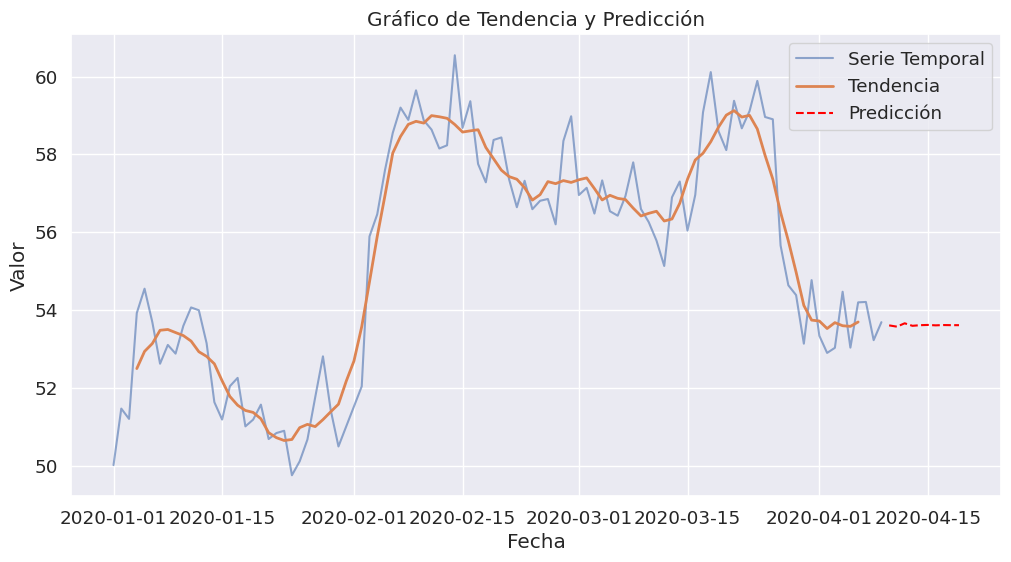

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Generar datos de ejemplo (serie temporal)
dates = pd.date_range(start='2020-01-01', periods=100, freq='D')
data = np.cumsum(np.random.randn(100)) + 50  # Datos con tendencia

df = pd.DataFrame({'Date': dates, 'Value': data})
df.set_index('Date', inplace=True)

# Descomposición de la serie temporal
result = seasonal_decompose(df, model='additive', period=7)
trend = result.trend.dropna()

# Ajustar un modelo ARIMA para la predicción
model = ARIMA(df, order=(5,1,0))  # (p,d,q)
model_fit = model.fit()
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

# Graficar la serie original, tendencia y predicción
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Value'], label='Serie Temporal', alpha=0.6)
plt.plot(trend.index, trend, label='Tendencia', linewidth=2)
plt.plot(pd.date_range(df.index[-1], periods=forecast_steps+1, freq='D')[1:],
         forecast, label='Predicción', linestyle='dashed', color='red')
plt.legend()
plt.title('Gráfico de Tendencia y Predicción')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.show()


### **Diagrama de árbol (para árboles de decisión)**

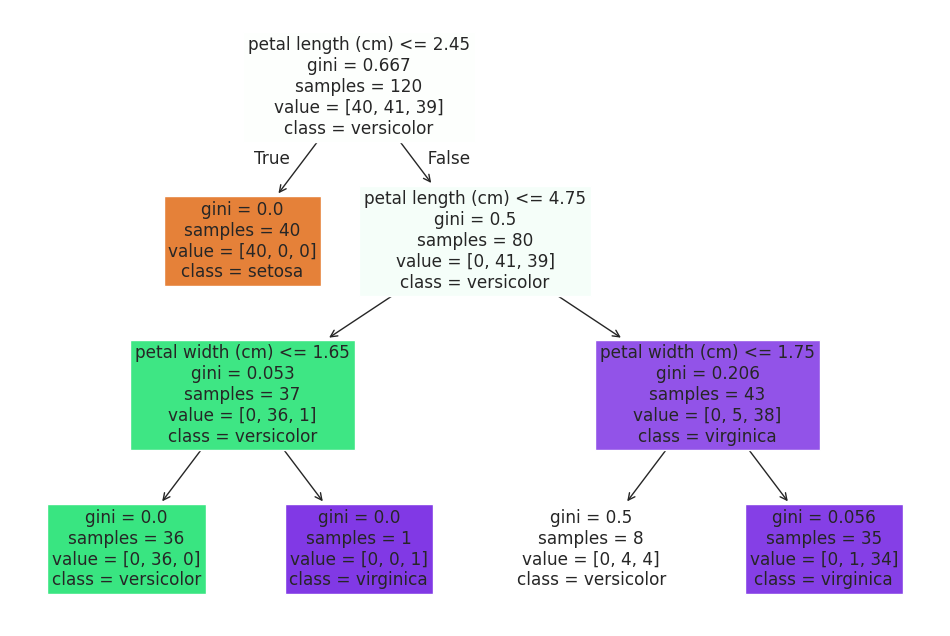

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# Cargar un conjunto de datos de ejemplo
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de árbol de decisión
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Graficar el árbol de decisión
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()
